In [ ]:
# pip install pennylane matplotlib qiskit qiskit-ibm-runtime
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from qiskit_ibm_runtime import QiskitRuntimeService

In [ ]:
def definir_hamiltoniano():
    """
    Construir el Hamiltoniano del sistema que quiero resolver.
    
    Entradas:
        Ninguna.
        
    Salidas:
        H (qml.Hamiltonian): El objeto Hamiltoniano de PennyLane listo para ser medido.
        
    Qué hace:
        Definir matemáticamente el problema físico. En este caso, crear el 
        Hamiltoniano H = Z_0*Z1 + X_0*X1, cuyo estado fundamental (energía mínima) 
        conozco teóricamente que es -2.0.
    """
    obs = [qml.PauliZ(0) @ qml.PauliZ(1), qml.PauliX(0) @ qml.PauliX(1)]
    coefs = [1.0, 1.0]
    return qml.Hamiltonian(coefs, obs)


def obtener_angulos_iniciales():
    """
    Generar el punto de partida para el optimizador clásico.
    
    Entradas:
        Ninguna.
        
    Salidas:
        params (tensor): Un arreglo de NumPy adaptado por PennyLane con 
                         requires_grad=True para permitir la diferenciación.
                         
    Qué hace:
        Asignar valores iniciales a los ángulos theta de las compuertas cuánticas. 
        Para el Ansatz 1, los valores óptimos teóricos son aproximadamente [-1.57, 3.14]. 
        Aquí devolver [-1.0, 2.5] para obligar al Gradiente Descendente a trabajar 
        y buscar el mínimo por su cuenta.
    """
    return np.array([-1.0, 2.5], requires_grad=True)


def ansatz(params, opcion=1):
    """
    Construir el circuito cuántico parametrizado (el Ansatz de Rayleigh-Ritz).
    
    Entradas:
        params (array-like): Lista o tensor con los ángulos a inyectar en las compuertas.
        opcion (int): Selector numérico (1 al 5) para cambiar la arquitectura del circuito.
        
    Salidas:
        Ninguna. (Aplicar las compuertas in-place en el QNode actual).
        
    Qué hace:
        Aplicar operaciones unitarias a los qubits. Contiene 5 arquitecturas distintas
        para experimentar con el concepto de "Expresividad vs Entrenabilidad".
        La Opción 1 es capaz de generar el entrelazamiento necesario para llegar 
        a la energía de -2.0 según la literatura.
    """
    if opcion == 1:
        qml.RY(params[0], wires=0)
        qml.RY(params[1], wires=1)
        qml.CNOT(wires=[0, 1])
        
    elif opcion == 2:
        qml.RY(params[0], wires=0)
        qml.RY(params[1], wires=1)
        
    elif opcion == 3:
        qml.RX(params[0], wires=0)
        qml.RZ(params[1], wires=1)
        qml.CNOT(wires=[0, 1])
        
    elif opcion == 4:
        qml.RY(params[0], wires=0)
        qml.RX(params[1], wires=1)
        qml.CZ(wires=[0, 1])
        qml.RY(params[0], wires=1)
        
    elif opcion == 5:
        qml.CNOT(wires=[0, 1])
        qml.RY(params[0], wires=0)
        qml.RY(params[1], wires=1)


def ejecutar_vqe_local(opcion_ansatz=1, pasos=50, tasa_aprendizaje=0.1):
    """
    Ejecutar el ciclo híbrido cuántico-clásico completo en mi computadora local.
    
    Entradas:
        opcion_ansatz (int): Qué circuito usar (por defecto 1).
        pasos (int): Número de iteraciones del descenso de gradiente (por defecto 50).
        tasa_aprendizaje (float): El step-size del optimizador (por defecto 0.1).
        
    Salidas:
        params (tensor): Los ángulos theta finales que minimizan la energía.
        
    Qué hace:
        1. Crear un simulador cuántico local de 2 qubits.
        2. Definir la función de costo (energía esperada).
        3. Instanciar el optimizador GradientDescentOptimizer.
        4. Iterar ajustando los parámetros para minimizar la energía.
        5. Imprimir el progreso de la optimización.
    """
    dev = qml.device("default.qubit", wires=2)
    H = definir_hamiltoniano()
    
    @qml.qnode(dev)
    def funcion_costo(params):
        ansatz(params, opcion=opcion_ansatz)
        return qml.expval(H)
    
    opt = qml.GradientDescentOptimizer(stepsize=tasa_aprendizaje)
    params = obtener_angulos_iniciales()
    
    print(f"--- Iniciando VQE Local (Ansatz {opcion_ansatz}) ---")
    print(f"Energía Inicial: {funcion_costo(params):.5f}")
    
    for i in range(pasos):
        params, energia = opt.step_and_cost(funcion_costo, params)
        if (i + 1) % 10 == 0:
            print(f"Paso {i + 1:2d} | Energía: {energia:.5f} | Ángulos: {params.numpy()}")
            
    print(f"Energía Final Optimizada: {energia:.5f}\n")
    return params


def enviar_job_xanadu(api_key, params_optimizados, opcion_ansatz=1):
    """
    Desplegar el circuito optimizado en un hardware cuántico real o simulador en la nube.
    
    Entradas:
        api_key (str): Mi token de acceso privado.
        params_optimizados (tensor): Los ángulos resultantes de ejecutar_vqe_local.
        opcion_ansatz (int): La misma arquitectura usada en el entrenamiento.
        
    Salidas:
        Ninguna. (Mostrar los resultados medidos en la consola).
        
    Qué hace:
        Aislar las credenciales e inicializar un dispositivo remoto (ej. cloud.qubit).
        Armar el circuito con los parámetros ya entrenados y pedir a la máquina remota 
        que ejecute mediciones (shots) reales para aproximar el valor esperado final.
    """
    print(f"Conectando al backend remoto con API KEY: {api_key[:4]}***...")
    
    try:
        dev_remote = qml.device("default.qubit", wires=2, shots=1024) 
        
        H = definir_hamiltoniano()
        
        @qml.qnode(dev_remote)
        def circuito_remoto(params):
            ansatz(params, opcion=opcion_ansatz)
            return qml.expval(H)
            
        energia_medida = circuito_remoto(params_optimizados)
        print(f"Job completado. Energía medida físicamente (1024 shots): {energia_medida:.5f}")
        
    except Exception as e:
        print(f"Error de conexión: {e}")

In [3]:
# Experimento 1: El Ansatz bueno (Logra llegar a -2.0)
print("EXPERIMENTO 1: Ansatz con Entrelazamiento")
params_buenos = ejecutar_vqe_local(opcion_ansatz=1, pasos=50)

# Experimento 2: El Ansatz malo (Queda atorado alrededor de -1.0 por el límite de Rayleigh-Ritz)
print("EXPERIMENTO 2: Ansatz sin Entrelazamiento (Muy simple)")
params_malos = ejecutar_vqe_local(opcion_ansatz=2, pasos=50)

EXPERIMENTO 1: Ansatz con Entrelazamiento
--- Iniciando VQE Local (Ansatz 1) ---
Energía Inicial: -1.64261
Paso 10 | Energía: -1.94137 | Ángulos: [-1.36607174  2.90973075]
Paso 20 | Energía: -1.99277 | Ángulos: [-1.49915627  3.06037369]
Paso 30 | Energía: -1.99912 | Ángulos: [-1.545806    3.11325735]
Paso 40 | Energía: -1.99989 | Ángulos: [-1.56208227  3.13171206]
Paso 50 | Energía: -1.99999 | Ángulos: [-1.5677579   3.13814748]
Energía Final Optimizada: -1.99999

EXPERIMENTO 2: Ansatz sin Entrelazamiento (Muy simple)
--- Iniciando VQE Local (Ansatz 2) ---
Energía Inicial: -0.93646
Paso 10 | Energía: -0.99881 | Ángulos: [-0.84032472  2.34032472]
Paso 20 | Energía: -0.99999 | Ángulos: [-0.82289354  2.32289354]
Paso 30 | Energía: -1.00000 | Ángulos: [-0.82102151  2.32102151]
Paso 40 | Energía: -1.00000 | Ángulos: [-0.82082051  2.32082051]
Paso 50 | Energía: -1.00000 | Ángulos: [-0.82079892  2.32079892]
Energía Final Optimizada: -1.00000



In [4]:
def visualizar_ansatz(opcion_ansatz=1):
    """
    Dibujar la arquitectura del circuito cuántico seleccionado.
    
    Entradas:
        opcion_ansatz (int): El número de Ansatz (1 al 5) que quiero visualizar.
        
    Salidas:
        Mostrar un diagrama en texto y un gráfico renderizado con Matplotlib.
    """
    # Necesitar un dispositivo y un QNode "de mentira" solo para poder dibujarlo
    dev_dibujo = qml.device("default.qubit", wires=2)
    
    @qml.qnode(dev_dibujo)
    def circuito_dummy(params):
        ansatz(params, opcion=opcion_ansatz)
        # El retorno no importar para el dibujo, solo poner una medición cualquiera
        return qml.expval(qml.PauliZ(0)) 
    
    # Crear unos ángulos arbitrarios solo para que el dibujante tenga qué mostrar
    angulos_ejemplo = np.array([1.23, -0.45])
    
    print(f"=== Arquitectura del Ansatz Opción {opcion_ansatz} ===")
    
    # 1. Dibujar en texto de forma rápida (útil si la gráfica falla o estar en terminal)
    print("\n[Versión Texto]")
    print(qml.draw(circuito_dummy)(angulos_ejemplo))
    
    # 2. Dibujar en formato gráfico (ideal para Jupyter Notebooks)
    print("\n[Versión Gráfica]")
    fig, ax = qml.draw_mpl(circuito_dummy, decimals=2)(angulos_ejemplo)
    plt.show()

=== Arquitectura del Ansatz Opción 3 ===

[Versión Texto]
0: ──RX(1.23)──╭●─┤  <Z>
1: ──RZ(-0.45)─╰X─┤     

[Versión Gráfica]


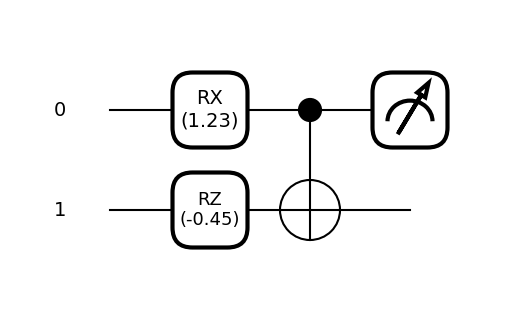

In [ ]:
# Cambia este número del 1 al 5 por ansatz para visualizar otros
visualizar_ansatz(opcion_ansatz=3) 


In [ ]:
# Credenciales
IBM_TOKEN = "Your_API_Key_Here" 
IBM_INSTANCE = "YourCRN_Instance_Here"  

# Preferencias del Hardware
MIN_QUBITS_REQUERIDOS = 2         
USAR_SIMULADOR_IBM = False        
SHOTS_MEDICION = 1024             

In [ ]:
def enviar_job_ibm_modular(params_optimizados, opcion_ansatz=1):
    """
    Enviar el circuito a IBM consumiendo las variables globales de configuración.
    """
    print("Autenticando con IBM Quantum...")
    try:
        service = QiskitRuntimeService(
            channel="ibm_cloud",   
            token=IBM_TOKEN,
            instance=IBM_INSTANCE    
        )
        print("Buscando el backend menos ocupado...")
        backend_ideal = service.least_busy(
            operational=True,
            simulator=USAR_SIMULADOR_IBM,
            min_num_qubits=MIN_QUBITS_REQUERIDOS
        )
        print(f"Hardware asignado: {backend_ideal.name}")  #Mostrar el backend seleccionado

        # Construir el dispositivo remoto de PennyLane
        dev_remote = qml.device(
            'qiskit.remote', 
            wires=MIN_QUBITS_REQUERIDOS, 
            backend=backend_ideal,
            shots=SHOTS_MEDICION
        )
        H = definir_hamiltoniano()

        @qml.qnode(dev_remote)
        def circuito_ibm(params):
            ansatz(params, opcion=opcion_ansatz)
            return qml.expval(H)

        print(f"Enviando el Ansatz {opcion_ansatz} a la fila de {backend_ideal.name}...")  #Indicar el envío al backend
        energia_medida = circuito_ibm(params_optimizados)
        print(f"¡Job Completado!")
        print(f"Energía medida: {energia_medida:.5f}")

    except Exception as e:
        print(f"Error en la ejecución remota: {e}")

In [ ]:
# Mandar a llamar a la función, pasándole los parámetros que entrené localmente
print("Iniciando secuencia de envío a IBM...")
enviar_job_ibm_modular(params_optimizados=params_buenos, opcion_ansatz=1)

qiskit_runtime_service._discover_account:WARNING:2026-05-02 17:09:27,875: Loading account with the given token. A saved account will not be used.


Iniciando secuencia de envío a IBM...
Autenticando con IBM Quantum...
Buscando el backend menos ocupado...
Hardware asignado: ibm_marrakesh


/opt/anaconda3/envs/xanadu/lib/python3.12/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


Enviando el Ansatz 1 a la fila de ibm_marrakesh...
¡Job Completado!
Energía medida: -1.98284
